Homework 3 - Question 4, part c

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
L = 200
phi0 = 0.4

epi = 0.02
v1 = -200

theta2 = 1 - phi0
v2 = -1 / np.tan(np.pi * theta2)

In [6]:
def qif(t, v, epi):
    v1, v2 = v

    dv1 = 1 + v1**2 + epi*(v2-v1)
    dv2 = 1 + v2**2 + epi*(v1-v2)

    return [dv1, dv2]

In [8]:
def spike1(t, v):
    return v[0] - L

def spike2(t, v):
    return v[1] - L

spike1.terminal = True
spike2.terminal = True

spike1.direction = 1
spike2.direction = 1

In [10]:
def sim(epi, ncycles=50):

    t = 0

    v1 = -200
    theta2 = 1 - phi0
    v2 = -1 / np.tan(np.pi * theta2)

    state = np.array([v1, v2])

    spike_times_1 = []
    spike_times_2 = []

    while len(spike_times_1) < ncycles:

        sol = solve_ivp(lambda t, v: qif(t, v, epi),[t, t + 10],state,events=[spike1, spike2],rtol=1e-8,atol=1e-10,max_step=0.01)

        # Determine which neuron spiked
        t1_events = sol.t_events[0]
        t2_events = sol.t_events[1]

        if len(t1_events) > 0:
            t_spike = t1_events[0]

            spike_times_1.append(t_spike)

            # State at spike
            state = sol.y_events[0][0].copy()

            # Reset neuron 1
            state[0] = -200

            t = t_spike

        elif len(t2_events) > 0:
            t_spike = t2_events[0]

            spike_times_2.append(t_spike)

            # State at spike
            state = sol.y_events[1][0].copy()

            # Reset neuron 2
            state[1] = -200

            t = t_spike

        else:
            break

    return np.array(spike_times_1), np.array(spike_times_2)

In [16]:
spike_t1, spike_t2 = sim(epi)

In [22]:
k = np.arange(len(spike_t1)-1)
phi_k = (spike_t2[k]- spike_t1[k]) / (spike_t1[k+1] - spike_t1[k])
phi_k

array([-0.57224667, -0.5811563 , -0.59105426, -0.60200766, -0.61407191,
       -0.627284  , -0.6416546 , -0.65715959, -0.67373214, -0.69125662,
       -0.70956651, -0.72844762, -0.74764769, -0.76689188, -0.78590189,
       -0.80441587, -0.82220534, -0.83908704, -0.85492829, -0.86964661,
       -0.88320474, -0.89560324, -0.9068719 , -0.9170616 , -0.92623705,
       -0.93447088, -0.9418391 , -0.94841778, -0.95428075, -0.95949812,
       -0.96413539, -0.96825303, -0.97190637, -0.97514563, -0.97801623,
       -0.98055897, -0.98281047, -0.98480345, -0.98656714, -0.98812754,
       -0.98950781, -0.99072852, -0.99180796, -0.99276233, -0.99360602,
       -0.99435177, -0.99501088, -0.99559335, -0.99610805])

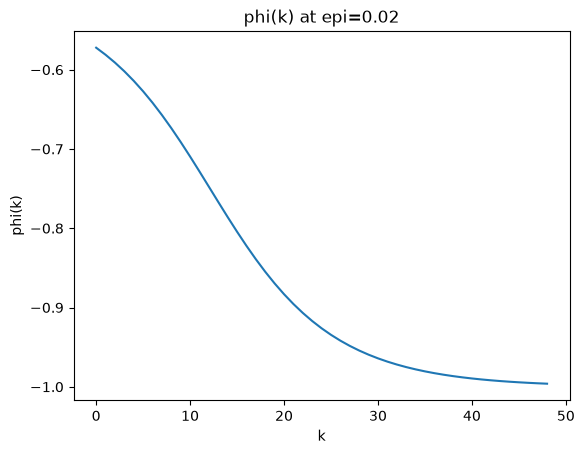

In [26]:
plt.plot(k, phi_k)
plt.xlabel('k')
plt.ylabel('phi(k)')
plt.title('phi(k) at epi=0.02')
plt.show()

Because epi=0.02 >0,the synchronous state phi =0 is a stable equilibrium, so phi(k) tends to exponentially 0 as k increases.

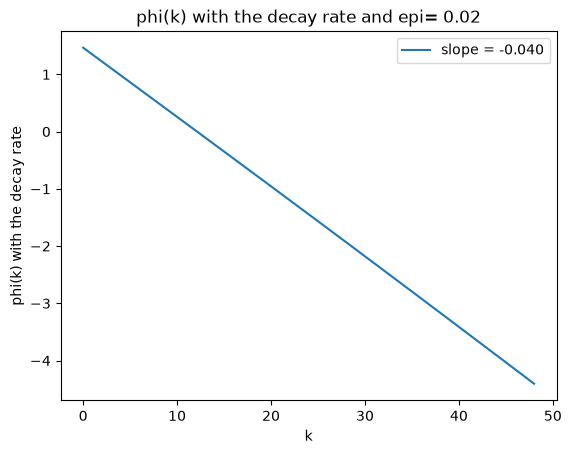

In [35]:
plt.plot(k,np.log(np.abs(np.tan(np.pi*phi_k))),label='slope = -0.040')
plt.xlabel('k')
plt.ylabel('phi(k) with the decay rate')
plt.title('phi(k) with the decay rate and epi= 0.02')
plt.legend()
plt.show()

In [37]:
spike_t1_le, spike_t2_le = sim(0.005)
spike_t1_he, spike_t2_he = sim(0.05)

In [39]:
phi_k_le = (spike_t2_le[k]- spike_t1_le[k]) / (spike_t1_le[k+1] - spike_t1_le[k])
phi_k_he = (spike_t2_he[k]- spike_t1_he[k]) / (spike_t1_he[k+1] - spike_t1_he[k])

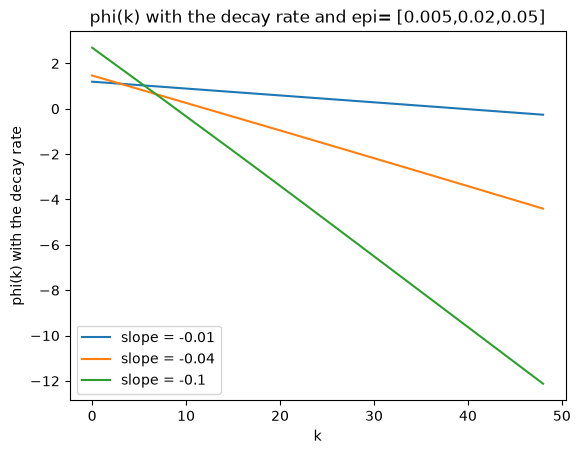

In [43]:
plt.plot(k,np.log(np.abs(np.tan(np.pi*phi_k_le))),label='slope = -0.01')
plt.plot(k,np.log(np.abs(np.tan(np.pi*phi_k))),label='slope = -0.04')
plt.plot(k,np.log(np.abs(np.tan(np.pi*phi_k_he))),label='slope = -0.1')
plt.xlabel('k')
plt.ylabel('phi(k) with the decay rate')
plt.title('phi(k) with the decay rate and epi= [0.005,0.02,0.05]')
plt.legend()
plt.show()

As epi increases, the slope increases as well. As epi tends to 0, the slope will tend to negative infinity, showcasing that the neurons will become uncoupled.

A symmetric cutoff is important because otherwise there would be an artificial phase shift introduced because of the cotangent. The true period wouldn't be able to happen.